## Упражнение 01. Линейный график со стилями

In [1]:
import pandas as pd
import sqlite3

### 1. Создаем соединение с базой данных с помощью библиотеки sqlite3

In [2]:
conn=sqlite3.connect('../data/checking-logs.sqlite')

### 2. Воссоздаем график в точности как на примере (и по данным, и по стилю):
#### - Анализируем только пользователей, без админов
#### - Учитываем только те даты, когда есть и просмотры, и коммиты из checker.


In [19]:
views_query= """
SELECT pageviews.datetime as datetime FROM pageviews
WHERE pageviews.uid like 'user_%'
"""
views = pd.io.sql.read_sql(views_query,conn,parse_dates=["datetime", ] )
views["date"] = views["datetime"].dt.date
views = views.groupby("date", ).size().reset_index(name="views", )
views

,date,views
0,2020-04-17,1
1,2020-04-18,23
2,2020-04-19,15
3,2020-04-21,3
4,2020-04-22,1
5,2020-04-23,5
6,2020-04-25,1
7,2020-04-26,8
8,2020-04-28,2
9,2020-04-29,4


In [22]:
commits_query = """
SELECT checker.timestamp AS datetime FROM checker 
WHERE checker.uid LIKE 'user_%';
"""
commits = pd.io.sql.read_sql(commits_query,conn,parse_dates=["datetime", ] )
commits["date"] = commits["datetime"].dt.date
commits = commits.groupby("date", ).size().reset_index(name="commits", )
commits

,date,commits
0,2020-04-17,23
1,2020-04-18,69
2,2020-04-19,33
3,2020-04-20,25
4,2020-04-21,25
5,2020-04-22,28
6,2020-04-23,43
7,2020-04-24,16
8,2020-04-25,104
9,2020-04-26,261


In [23]:
df=pd.merge(views,commits,on="date", how="inner")
df

,date,views,commits
0,2020-04-17,1,23
1,2020-04-18,23,69
2,2020-04-19,15,33
3,2020-04-21,3,25
4,2020-04-22,1,28
5,2020-04-23,5,43
6,2020-04-25,1,104
7,2020-04-26,8,261
8,2020-04-28,2,5
9,2020-04-29,4,17


#### - Размер шрифта — 8;
#### - Размер фигуры — (15, 8);
#### - Заголовок графика — "Views per day";

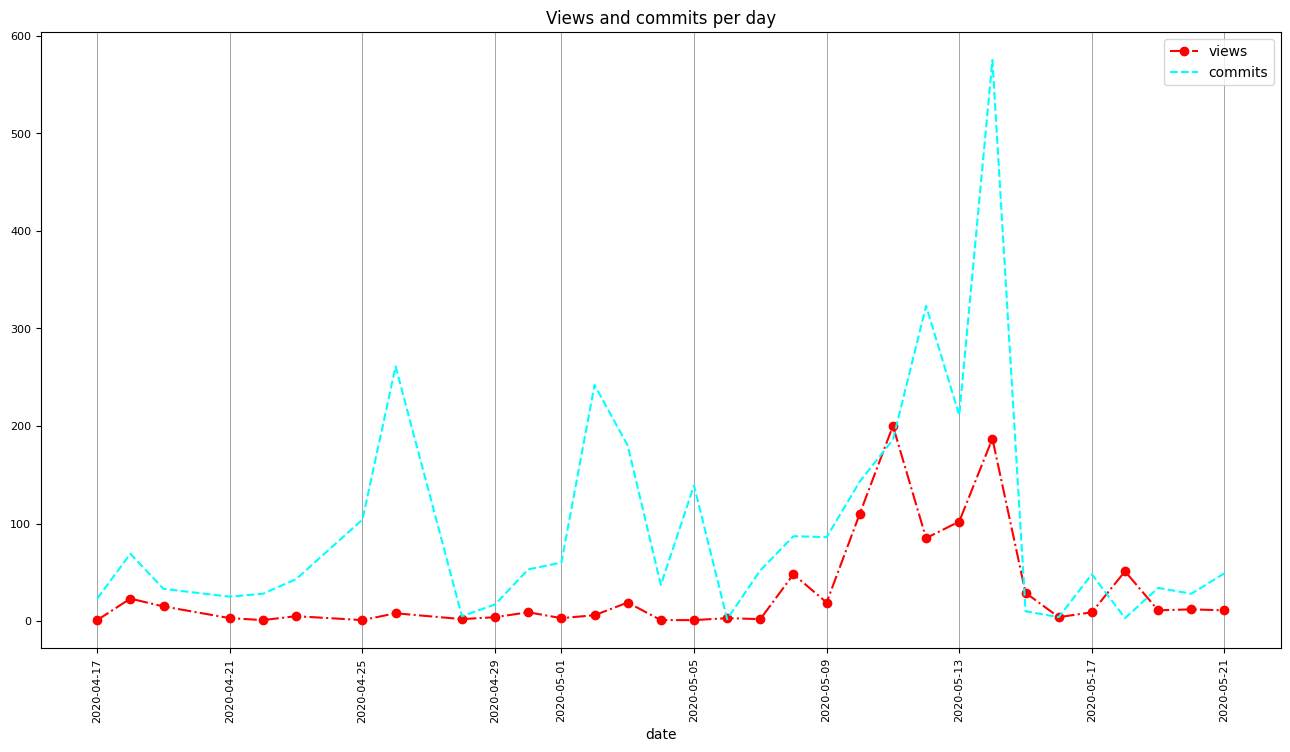

In [ ]:
ax = df.plot(
    x="date",
    style=["o-.", "--", ],
    color=["red", "cyan", ],
    fontsize=8,
    figsize=(15, 8, ),
    legend=["views", "commits", ],
    title="Views and commits per day",
    rot=90,
)
ax.grid(
    visible=True,
    axis='x',
    color="grey",
    linestyle='-',
    linewidth=0.5,
)

### Сколько раз число просмотров превышало 150?

In [29]:
print(f"Ответ {df[df["views"] > 150].shape[0]}", )

Ответ 2


### Закрываем соединение с базой данных.

In [30]:
conn.close()